--- Problem 1: Bridge Deformation ---
Calculated Coefficients: a = 0.15, b = -3.00, c = 0.00
Estimated deflection at x = 5m: -11.25 mm


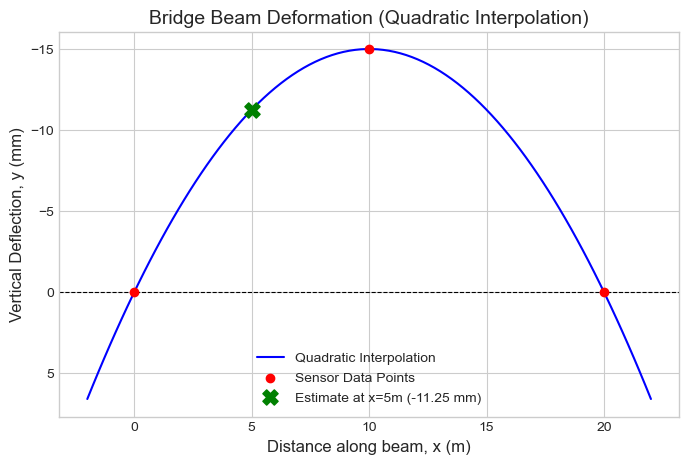

In [1]:
"""
SOLUTION LOGIC:
1. Math: To find the quadratic polynomial P(x) = ax^2 + bx + c, we plug our 3 known (x, y) 
   sensor readings into the equation. This generates a system of 3 linear equations. 
   By expressing this in matrix form (Ax = b), we can solve for coefficients a, b, and c.
2. Code: Instead of manual substitution, we use numpy to build the A matrix and b vector, 
   then use np.linalg.solve() to compute the exact coefficients instantly. Finally, we 
   evaluate the polynomial at x=5 and use matplotlib to visualize the bent bridge beam.
"""

import numpy as np
import matplotlib.pyplot as plt

# 1. Define the known data points from the sensors
x_data = np.array([0, 10, 20])
y_data = np.array([0, -15, 0])

# 2. Set up the system of equations (Ax = b) using the Direct Method
# The matrix A consists of [x^2, x, 1] for each x data point
A = np.vstack([x_data**2, x_data, np.ones(len(x_data))]).T
b = y_data

# 3. Solve for the coefficients a, b, and c
coefficients = np.linalg.solve(A, b)
a, b_coeff, c = coefficients

print("--- Problem 1: Bridge Deformation ---")
print(f"Calculated Coefficients: a = {a:.2f}, b = {b_coeff:.2f}, c = {c:.2f}")

# 4. Estimate the deflection at the center (x = 5m)
x_estimate = 5
y_estimate = a * (x_estimate**2) + b_coeff * x_estimate + c
print(f"Estimated deflection at x = {x_estimate}m: {y_estimate:.2f} mm")

# 5. Data Visualization (Plotting)
x_curve = np.linspace(-2, 22, 100)
y_curve = a * (x_curve**2) + b_coeff * x_curve + c

plt.figure(figsize=(8, 5))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(x_curve, y_curve, label='Quadratic Interpolation', color='blue')
plt.scatter(x_data, y_data, color='red', zorder=5, label='Sensor Data Points')
plt.scatter(x_estimate, y_estimate, color='green', marker='X', s=120, zorder=5, 
            label=f'Estimate at x=5m ({y_estimate:.2f} mm)')

plt.title("Bridge Beam Deformation (Quadratic Interpolation)", fontsize=14)
plt.xlabel("Distance along beam, x (m)", fontsize=12)
plt.ylabel("Vertical Deflection, y (mm)", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') 
plt.gca().invert_yaxis() # Show downward deflection visually
plt.legend()
plt.grid(True)
plt.show()

--- Problem 2: Thermodynamics ---
Calculated Coefficients: a = 0.00125, b = -2.00, c = 850.00
Quadratic prediction at 500°C: 162.50 mPa·s
Linear prediction at 500°C: 175.00 mPa·s


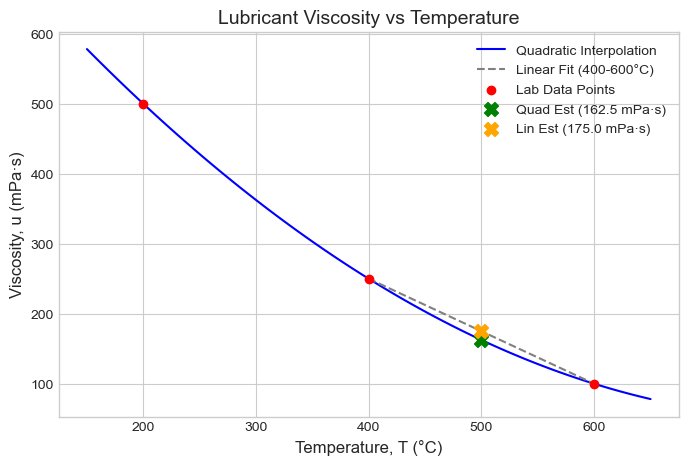

In [2]:
"""
====================================================================
MANUAL SOLUTION PROCESS (Direct Method via Elimination):
We start with p(T) = aT^2 + bT + c and plug in our (T, u) data:
Eq 1: 40000a + 200b + c = 500  (from T=200, u=500)
Eq 2: 160000a + 400b + c = 250 (from T=400, u=250)
Eq 3: 360000a + 600b + c = 100 (from T=600, u=100)

Step 1: Eliminate 'c'
Subtract Eq 1 from Eq 2 -> 120000a + 200b = -250 (Eq 4)
Subtract Eq 2 from Eq 3 -> 200000a + 200b = -150 (Eq 5)

Step 2: Eliminate 'b' to solve for 'a'
Subtract Eq 4 from Eq 5 -> 80000a = 100
a = 100 / 80000 = 0.00125

Step 3: Solve for 'b' (using Eq 4)
120000(0.00125) + 200b = -250
150 + 200b = -250 -> 200b = -400 -> b = -2

Step 4: Solve for 'c' (using Eq 1)
40000(0.00125) + 200(-2) + c = 500
50 - 400 + c = 500 -> -350 + c = 500 -> c = 850
====================================================================
"""

import numpy as np
import matplotlib.pyplot as plt

# 1. Define the known lab data
T_data = np.array([200, 400, 600])
u_data = np.array([500, 250, 100])

# 2. Set up the system of equations (Ax = b) for the numerical solver
A = np.vstack([T_data**2, T_data, np.ones(len(T_data))]).T
b = u_data

# 3. Solve for coefficients using numpy
coeffs = np.linalg.solve(A, b)
a, b_coeff, c = coeffs

print("--- Problem 2: Thermodynamics ---")
print(f"Calculated Coefficients: a = {a:.5f}, b = {b_coeff:.2f}, c = {c:.2f}")

# 4. Predict at T = 500C (Quadratic)
T_est = 500
u_quad_est = a * (T_est**2) + b_coeff * T_est + c
print(f"Quadratic prediction at {T_est}°C: {u_quad_est:.2f} mPa·s")

# Compute Linear Interpolation at T = 500C (between 400 and 600)
m_slope = (100 - 250) / (600 - 400)
c_intercept = 250 - m_slope * 400
u_lin_est = m_slope * T_est + c_intercept
print(f"Linear prediction at {T_est}°C: {u_lin_est:.2f} mPa·s")

# 5. Data Visualization (Plotting)
T_curve = np.linspace(150, 650, 100)
u_curve = a * (T_curve**2) + b_coeff * T_curve + c

plt.figure(figsize=(8, 5))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(T_curve, u_curve, label='Quadratic Interpolation', color='blue')
plt.plot([400, 600], [250, 100], label='Linear Fit (400-600°C)', color='gray', linestyle='--')

plt.scatter(T_data, u_data, color='red', zorder=5, label='Lab Data Points')
plt.scatter(T_est, u_quad_est, color='green', marker='X', s=100, zorder=5, 
            label=f'Quad Est ({u_quad_est:.1f} mPa·s)')
plt.scatter(T_est, u_lin_est, color='orange', marker='X', s=100, zorder=5, 
            label=f'Lin Est ({u_lin_est:.1f} mPa·s)')

plt.title("Lubricant Viscosity vs Temperature", fontsize=14)
plt.xlabel("Temperature, T (°C)", fontsize=12)
plt.ylabel("Viscosity, u (mPa·s)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

--- Problem 3: Aerospace Engineering ---
Calculated Coefficients: a3 = 0.0000, a2 = 30.0000, a1 = -20.0000, a0 = 40.0000
Note: Since a3 evaluates to 0, the trajectory physically acts as a quadratic curve (constant acceleration).

Estimated vertical velocity at t = 2.5s: 130.00 m/s
Estimated vertical velocity at t = 3.73s: 203.80 m/s


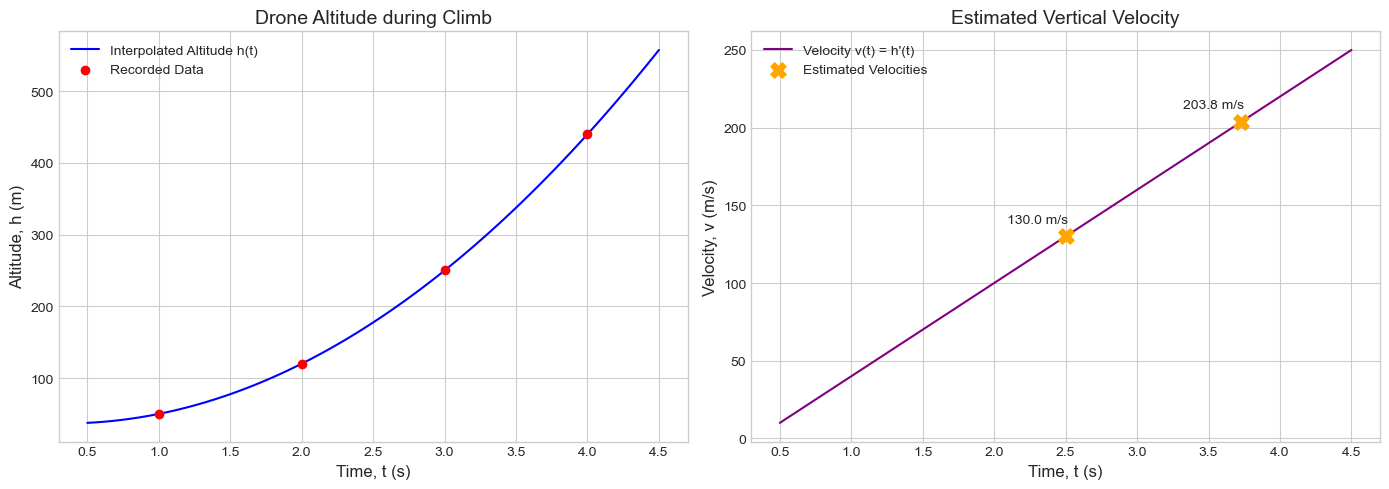

In [3]:
"""
====================================================================
MANUAL SOLUTION PROCESS (Gaussian Elimination):
We start with h(t) = a3*t^3 + a2*t^2 + a1*t + a0 and plug in (t, h):
Eq 1:  1*a3 +  1*a2 +  1*a1 + 1*a0 = 50   (from t=1, h=50)
Eq 2:  8*a3 +  4*a2 +  2*a1 + 1*a0 = 120  (from t=2, h=120)
Eq 3: 27*a3 +  9*a2 +  3*a1 + 1*a0 = 250  (from t=3, h=250)
Eq 4: 64*a3 + 16*a2 +  4*a1 + 1*a0 = 440  (from t=4, h=440)

Step 1: Eliminate a3 from Eq 2, 3, 4 using Eq 1
R2 -  8*R1 ->  0*a3 -  4*a2 -  6*a1 -  7*a0 = -280
R3 - 27*R1 ->  0*a3 - 18*a2 - 24*a1 - 26*a0 = -1100
R4 - 64*R1 ->  0*a3 - 48*a2 - 60*a1 - 63*a0 = -2760

Step 2: Eliminate a2 from new Eq 3, 4 using new Eq 2
R3 - 4.5*R2 -> 0*a2 +  3*a1 + 5.5*a0 = 160
R4 -  12*R2 -> 0*a2 + 12*a1 +  21*a0 = 600

Step 3: Eliminate a1 from new Eq 4 using new Eq 3
R4 -   4*R3 -> 0*a1 - 1*a0 = -40

Step 4: Back-Substitution (Bottom to Top)
From R4: -1*a0 = -40                    -> a0 = 40
From R3: 3*a1 + 5.5(40) = 160           -> a1 = -20
From R2: -4*a2 - 6(-20) - 7(40) = -280  -> a2 = 30
From R1: 1*a3 + 30 - 20 + 40 = 50       -> a3 = 0
====================================================================
"""

import numpy as np
import matplotlib.pyplot as plt

# 1. Define the known drone flight data
t_data = np.array([1, 2, 3, 4])
h_data = np.array([50, 120, 250, 440])

# 2. Set up the 4x4 system of equations (Ax = b)
A = np.vstack([t_data**3, t_data**2, t_data, np.ones(len(t_data))]).T
b = h_data

# 3. Solve for cubic coefficients
coeffs = np.linalg.solve(A, b)
a3, a2, a1, a0 = coeffs

print("--- Problem 3: Aerospace Engineering ---")
# Note: Because of floating-point precision, a3 will be exceptionally close to 0 (e.g., 1e-15)
# We will round it for a clean presentation.
print(f"Calculated Coefficients: a3 = {a3:.4f}, a2 = {a2:.4f}, a1 = {a1:.4f}, a0 = {a0:.4f}")
print("Note: Since a3 evaluates to 0, the trajectory physically acts as a quadratic curve (constant acceleration).\n")

# Define functions for altitude and velocity
def altitude(t):
    return a3*(t**3) + a2*(t**2) + a1*t + a0

def velocity(t):
    # Derivative: h'(t) = 3*a3*t^2 + 2*a2*t + a1
    return 3*a3*(t**2) + 2*a2*t + a1

# 4. Estimate velocity at given times
t_v1 = 2.5
t_v2 = 3.73
print(f"Estimated vertical velocity at t = {t_v1}s: {velocity(t_v1):.2f} m/s")
print(f"Estimated vertical velocity at t = {t_v2}s: {velocity(t_v2):.2f} m/s")

# 5. Data Visualization (Plotting Altitude and Velocity)
t_curve = np.linspace(0.5, 4.5, 100)
h_curve = altitude(t_curve)
v_curve = velocity(t_curve)

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plt.style.use('seaborn-v0_8-whitegrid')

# Left Plot: Altitude vs Time
ax1.plot(t_curve, h_curve, color='blue', label='Interpolated Altitude h(t)')
ax1.scatter(t_data, h_data, color='red', zorder=5, label='Recorded Data')
ax1.set_title("Drone Altitude during Climb", fontsize=14)
ax1.set_xlabel("Time, t (s)", fontsize=12)
ax1.set_ylabel("Altitude, h (m)", fontsize=12)
ax1.legend()
ax1.grid(True)

# Right Plot: Velocity vs Time
ax2.plot(t_curve, v_curve, color='purple', label="Velocity v(t) = h'(t)")
ax2.scatter([t_v1, t_v2], [velocity(t_v1), velocity(t_v2)], color='orange', marker='X', s=120, zorder=5, 
            label='Estimated Velocities')
# Annotate the specific velocity points
ax2.annotate(f"{velocity(t_v1):.1f} m/s", (t_v1, velocity(t_v1)), textcoords="offset points", xytext=(-20,10), ha='center')
ax2.annotate(f"{velocity(t_v2):.1f} m/s", (t_v2, velocity(t_v2)), textcoords="offset points", xytext=(-20,10), ha='center')

ax2.set_title("Estimated Vertical Velocity", fontsize=14)
ax2.set_xlabel("Time, t (s)", fontsize=12)
ax2.set_ylabel("Velocity, v (m/s)", fontsize=12)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

--- Problem 4: Signal Processing ---
Calculated Lagrange Polynomial (Simplified):
0.0 + 1.06666667 x - 0.25 x**2 - 0.01666667 x**3

Estimated voltage at t = 1.5 ms: 0.98125 V



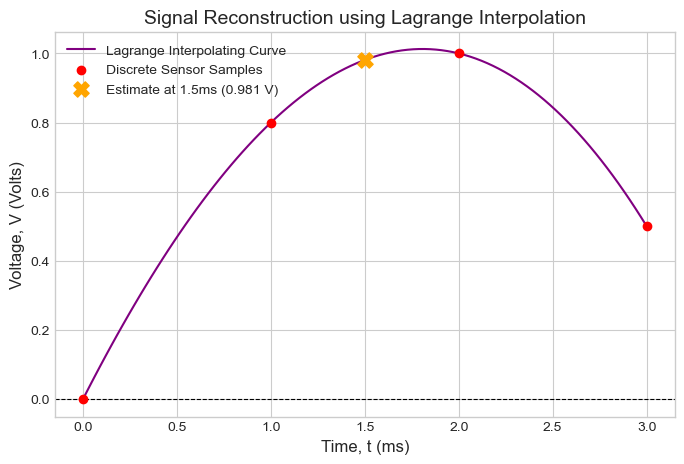

In [4]:
"""
====================================================================
MANUAL SOLUTION PROCESS (Lagrange Interpolation):
Formula: P(t) = sum( V_i * L_i(t) )
Where L_i(t) = product( (t - t_j) / (t_i - t_j) ) for j != i

Given data: (0, 0.0), (1, 0.8), (2, 1.0), (3, 0.5)
Since V(0) = 0, we can skip L_0(t).

L_1(t) = [t(t-2)(t-3)] / [(1)(1-2)(1-3)] = (t^3 - 5t^2 + 6t) / 2
L_2(t) = [t(t-1)(t-3)] / [(2)(2-1)(2-3)] = (t^3 - 4t^2 + 3t) / -2
L_3(t) = [t(t-1)(t-2)] / [(3)(3-1)(3-2)] = (t^3 - 3t^2 + 2t) / 6

P(t) = 0.8*L_1(t) + 1.0*L_2(t) + 0.5*L_3(t)

Evaluating at t = 1.5:
L_1(1.5) = 0.5625
L_2(1.5) = 0.5625
L_3(1.5) = -0.0625
V(1.5) = 0.8(0.5625) + 1.0(0.5625) + 0.5(-0.0625) = 0.98125 V
====================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from numpy.polynomial.polynomial import Polynomial

# 1. Define the known discrete voltage samples
t_data = np.array([0, 1, 2, 3])
v_data = np.array([0.0, 0.8, 1.0, 0.5])

# 2. Compute the Lagrange Interpolation Polynomial using SciPy
# Note: lagrange returns coefficients in highest-to-lowest order (t^3, t^2, t, 1)
poly_lagrange = lagrange(t_data, v_data)

print("--- Problem 4: Signal Processing ---")
# To print the polynomial neatly, we can use the Polynomial class
# We reverse the coefficients because Polynomial() expects lowest-to-highest
clean_poly = Polynomial(poly_lagrange.coef[::-1])
print("Calculated Lagrange Polynomial (Simplified):")
print(clean_poly)

# 3. Calculate estimated voltage at t = 1.5 ms
t_est = 1.5
v_est = poly_lagrange(t_est)
print(f"\nEstimated voltage at t = {t_est} ms: {v_est:.5f} V\n")

# 4. Data Visualization
t_curve = np.linspace(0, 3, 100)
v_curve = poly_lagrange(t_curve)

plt.figure(figsize=(8, 5))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(t_curve, v_curve, label='Lagrange Interpolating Curve', color='purple')
plt.scatter(t_data, v_data, color='red', zorder=5, label='Discrete Sensor Samples')
plt.scatter(t_est, v_est, color='orange', marker='X', s=120, zorder=5, 
            label=f'Estimate at 1.5ms ({v_est:.3f} V)')

plt.title("Signal Reconstruction using Lagrange Interpolation", fontsize=14)
plt.xlabel("Time, t (ms)", fontsize=12)
plt.ylabel("Voltage, V (Volts)", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

--- Problem 5: Chemical Engineering ---
Quadratic Polynomial: C(t) = 0.003t^2 -0.095t + 1.00
Time to reach 0.5 mol/L: 6.67 min
Linear Fit: L(t) = -0.065t + 0.975

Extrapolation to t=20 min:
Quadratic prediction: 0.30 mol/L
Linear prediction: -0.325 mol/L (Unphysical - negative concentration)


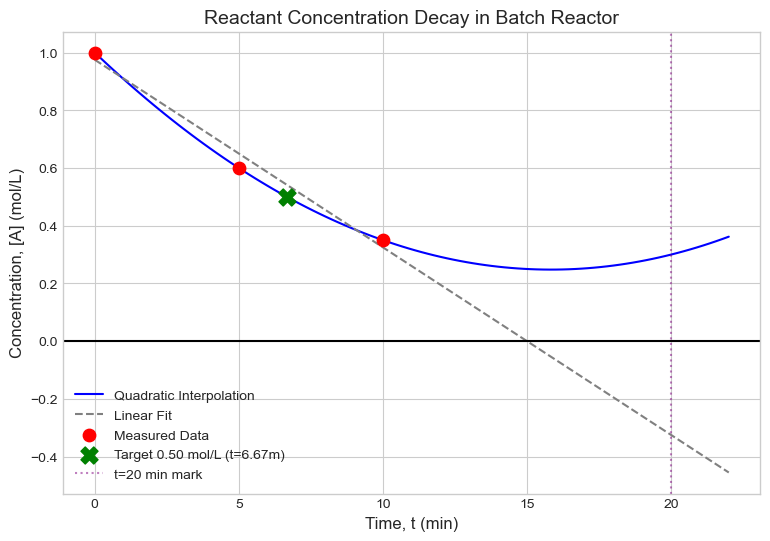

In [5]:
"""
====================================================================
MANUAL SOLUTION PROCESS:
1. Quadratic Interpolation: Set up system with C(t) = at^2 + bt + c.
   t=0: c = 1.00
   t=5: 25a + 5b + 1.00 = 0.60
   t=10: 100a + 10b + 1.00 = 0.35
   Solving yields: a = 0.003, b = -0.095, c = 1.00

2. Find t when C(t) = 0.50:
   0.003t^2 - 0.095t + 0.50 = 0
   Using quadratic formula, roots are t = 25 min and t = 6.667 min.
   The relevant time for the reactor is 6.667 min.

3. Least Squares Linear Fit:
   Using linear regression formulas, line of best fit is y = -0.065t + 0.975
   Extrapolating to t=20 gives -0.325 (unphysical) vs Quadratic 0.30.
====================================================================
"""

import numpy as np
import matplotlib.pyplot as plt

# 1. Define reactor data
t_data = np.array([0, 5, 10])
c_data = np.array([1.00, 0.60, 0.35])

# 2. Construct Interpolating Polynomial (Quadratic)
# np.polyfit returns coefficients highest-power first
quad_coeffs = np.polyfit(t_data, c_data, 2)
a, b, c = quad_coeffs

print("--- Problem 5: Chemical Engineering ---")
print(f"Quadratic Polynomial: C(t) = {a:.3f}t^2 {b:.3f}t + {c:.2f}")

# 3. Solve for t when C(t) = 0.50
# We want the roots of: at^2 + bt + (c - 0.50) = 0
target_c = 0.50
roots = np.roots([a, b, c - target_c])
# Filter for the relevant root (the earlier time during the reaction)
target_t = min([r for r in roots if r > 0])
print(f"Time to reach {target_c} mol/L: {target_t:.2f} min")

# 4. Least Squares Linear Fit
lin_coeffs = np.polyfit(t_data, c_data, 1)
m, y_int = lin_coeffs
print(f"Linear Fit: L(t) = {m:.3f}t + {y_int:.3f}")

# Compare at t = 20 min
t_extrapolate = 20
c_quad_20 = np.polyval(quad_coeffs, t_extrapolate)
c_lin_20 = np.polyval(lin_coeffs, t_extrapolate)
print(f"\nExtrapolation to t=20 min:")
print(f"Quadratic prediction: {c_quad_20:.2f} mol/L")
print(f"Linear prediction: {c_lin_20:.3f} mol/L (Unphysical - negative concentration)")

# 5. Data Visualization
t_curve = np.linspace(0, 22, 100)
c_quad_curve = np.polyval(quad_coeffs, t_curve)
c_lin_curve = np.polyval(lin_coeffs, t_curve)

plt.figure(figsize=(9, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot the models
plt.plot(t_curve, c_quad_curve, label='Quadratic Interpolation', color='blue')
plt.plot(t_curve, c_lin_curve, label='Linear Fit', color='gray', linestyle='--')

# Plot the data points and target
plt.scatter(t_data, c_data, color='red', zorder=5, s=80, label='Measured Data')
plt.scatter(target_t, target_c, color='green', marker='X', s=150, zorder=5, 
            label=f'Target 0.50 mol/L (t={target_t:.2f}m)')

# Formatting
plt.title("Reactant Concentration Decay in Batch Reactor", fontsize=14)
plt.xlabel("Time, t (min)", fontsize=12)
plt.ylabel("Concentration, [A] (mol/L)", fontsize=12)
plt.axhline(0, color='black', linewidth=1.5) # Zero concentration baseline
plt.axvline(20, color='purple', linestyle=':', alpha=0.5, label='t=20 min mark')
plt.legend()
plt.grid(True)
plt.show()